# Telco Churn Project

## Importing libraries

In [2]:
# data manipulation
import pandas as pd
import numpy as np

# data viz
import matplotlib.pyplot as plt
import seaborn as sns

# ML


## Data Exploration

In [3]:
#reading data
df = pd.read_csv("./data/kaggle_telco.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Data types

Looking at the data types, there are two things that come to attention. The "SeniorCitizen" column is one-hot encoded, which can be kept this way. But also, "TotalCharges" is a string instead of float.

In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

When trying to make "TotalCharges" into a numeric variable, an error gets thrown because there are some missing values, here as " ". To be sure, I filter those for all columns.

In [5]:
df_filtered = df[(df != " ").all(axis=1)]

In [6]:
df_filtered["TotalCharges"]=pd.to_numeric(df_filtered["TotalCharges"], errors="coerce")

df_filtered.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [7]:
df_filtered.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
#df_filtered.sample(10)
df_filtered.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


#### Dupliactes

In [9]:
# find dupliactes
duplicates_bool = df_filtered.duplicated()
duplicates_bool.value_counts() # no duplicates

False    7032
Name: count, dtype: int64

#### Boxplots
Plotting boxplots to get a first look on the numeric cols and to find outliers.

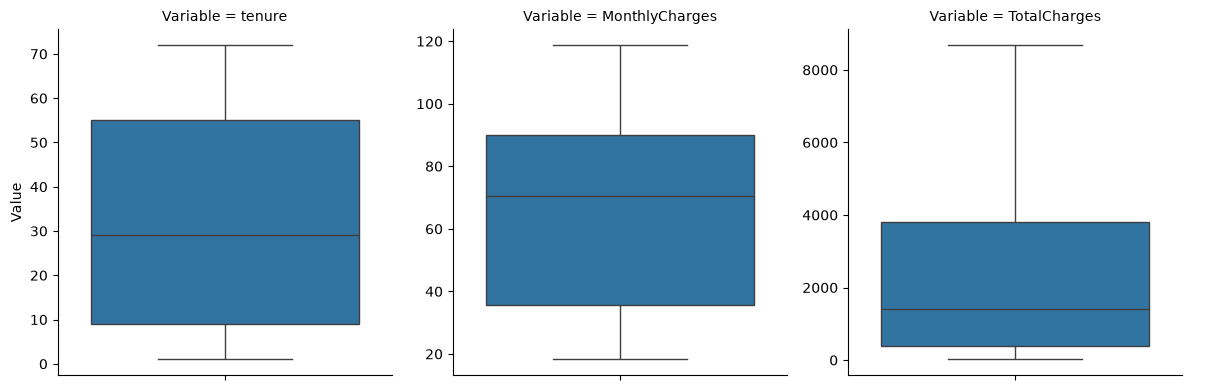

In [10]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df_melted = df_filtered[numeric_cols + ["Churn", "gender"]].melt(id_vars=["Churn", "gender"], var_name="Variable", value_name="Value")


g = sns.catplot(
    data=df_melted, y="Value",
    col="Variable", kind="box",
    col_wrap=3, sharey=False, height=4
)
plt.show()

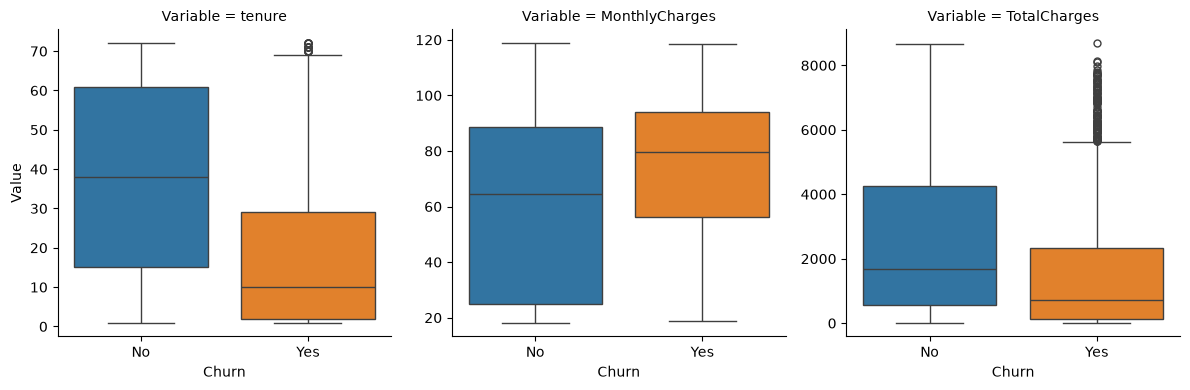

In [11]:
g = sns.catplot(
    data=df_melted, x="Churn", y="Value", hue="Churn",
    col="Variable", kind="box",
    col_wrap=3, sharey=False, height=4
)
plt.show()

#### Distributions (numeric)

<Axes: xlabel='tenure', ylabel='Count'>

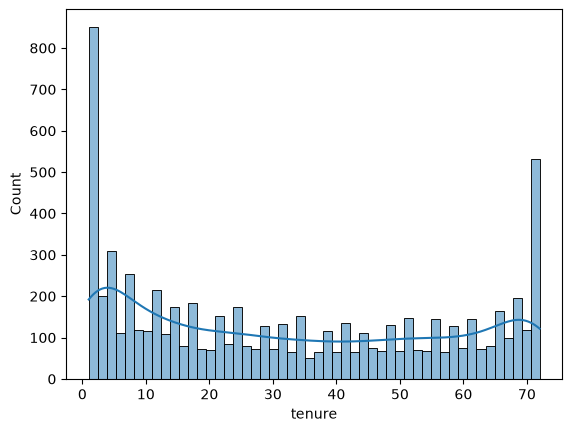

In [12]:
sns.histplot(data=df_filtered, x = "tenure", kde = True, bins = 50)
## looks like a beta distribution with a=b=0.5 (arcsin distribution)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

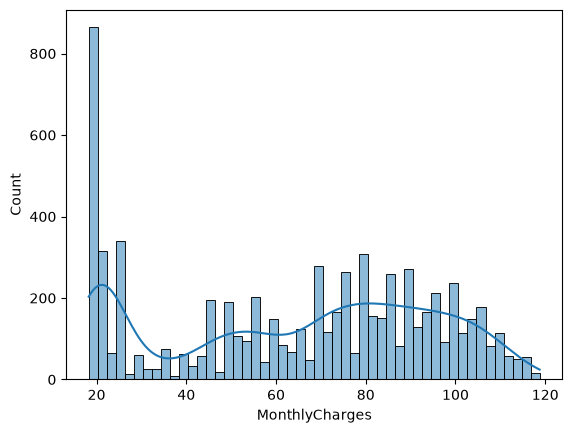

In [13]:
sns.histplot(data=df_filtered, x = "MonthlyCharges", kde = True, bins = 50)

<Axes: xlabel='TotalCharges', ylabel='Count'>

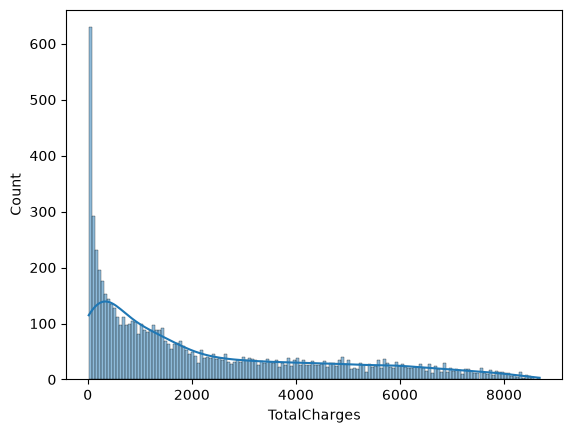

In [ ]:
sns.histplot(data=df_filtered, x = "TotalCharges", kde=True, bins = 150)
# looks like expon

Using violin plots, we can see some interaction between "MonthlyCharges" and "Churn". The plot shows, that churned customers often paid high monthly fees.
At the same time, and not surprisingly, most churned customers left early into their tenure.

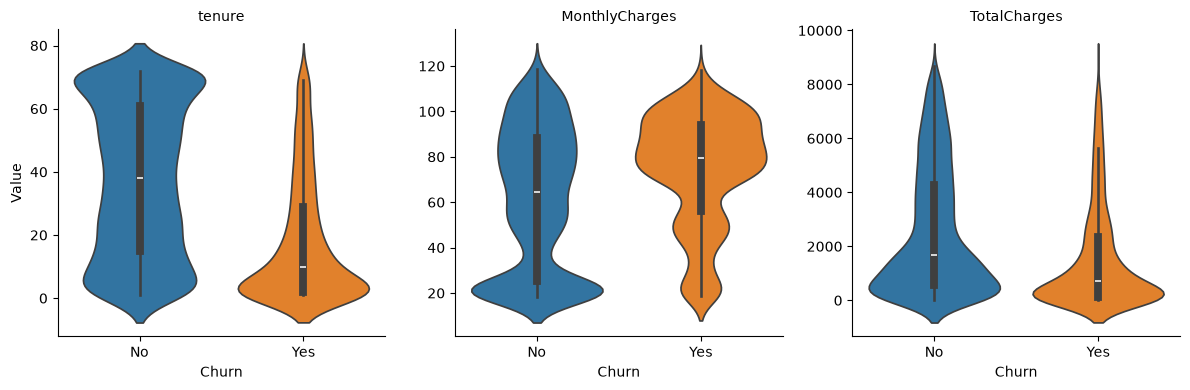

In [45]:
g = sns.catplot(
    data=df_melted, x="Churn", y="Value", hue = "Churn",
    col="Variable", kind='violin',
    col_wrap=3, sharey=False, height=4
)
g.set_titles("{col_name}")
plt.show()

#### Distributions (categorical)

In [54]:
cat_cols = ["gender","SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "Churn"]

for col in cat_cols:
    print(df[col].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: c

<Axes: xlabel='SeniorCitizen', ylabel='count'>

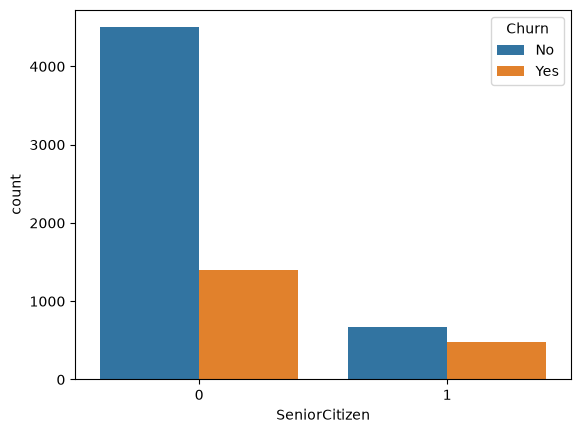

In [ ]:
# some cols that are failry imbalanced and that I want to have a closer look at
imb_cols = ["SeniorCitizen", "PhoneService", "InternetService", "Contract"]

sns.countplot(data=df_filtered, x = "SeniorCitizen", hue="Churn")

<Axes: xlabel='PhoneService', ylabel='count'>

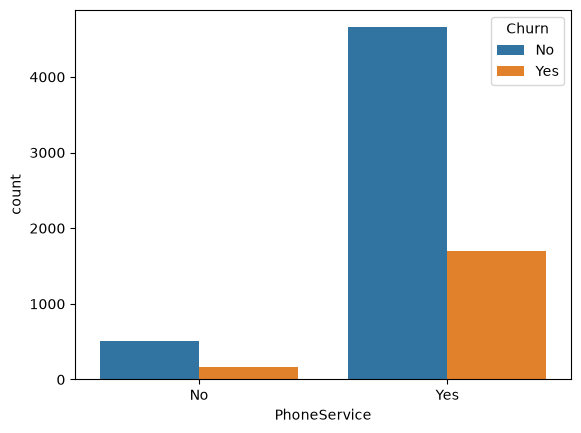

In [69]:
sns.countplot(data=df_filtered, x = "PhoneService", hue="Churn")


The following plot shows that customers whose contract contains the fibreglas option, have a much higher churn rate than the other categories of "InternetService".

<Axes: xlabel='InternetService', ylabel='count'>

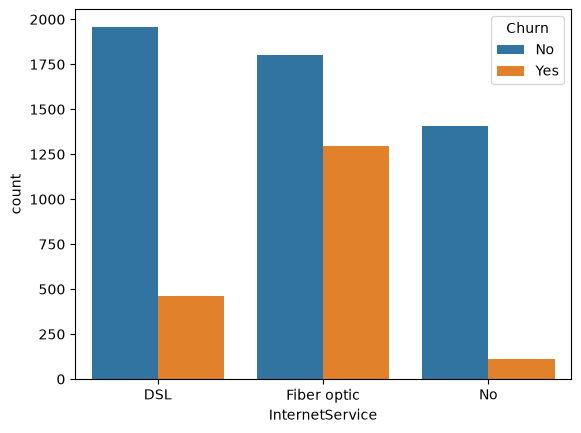

In [70]:
sns.countplot(data=df_filtered, x = "InternetService", hue="Churn")

The following plot shows that customers with month-to-month contract have much higher churn rates than other contract. This is not surprising.

<Axes: xlabel='Contract', ylabel='count'>

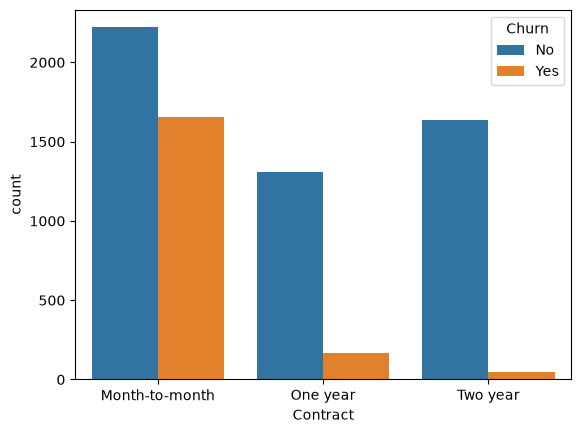

In [71]:
sns.countplot(data=df_filtered, x = "Contract", hue="Churn")
